In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.config import Config
from src.appliance import Appliance
from src.data_loader import load_and_clean_data, validate_data, auto_discover_appliances
from src.optimizer import GAScheduler, brute_force_search
from src.evaluation import evaluate_schedule, savings, self_consumption, self_sufficiency
from src.plotting import plot_schedule

print("✅ Academic Optimization Environment & Full Engine Loaded.")

✅ Academic Optimization Environment & Full Engine Loaded.


In [8]:
config = Config("config.yaml")
file_path = config.get("data.file_path")
power_unit = config.get("data.power_unit", "kW")

# Phase 8: Auto-Discovery
discovered_appliances_config = auto_discover_appliances(
    file_path=file_path,
    appliances_config=config.get("appliances", []),
    power_unit=power_unit
)

# Ensure time windows exist
for app_dict in discovered_appliances_config:
    if 'window_start' not in app_dict: app_dict['window_start'] = 0
    if 'window_end' not in app_dict: app_dict['window_end'] = 23

appliances = [Appliance(**app) for app in discovered_appliances_config]

df = load_and_clean_data(file_path, config.get("data.timestamp_column"), config.get("data.pv_column"), config.get("data.load_column"), config.get("data.frequency", "h"), power_unit)
validate_data(df)

pv_series = df['pv_kw'].to_numpy()
base_load = df['load_kw'].to_numpy()

print(f"✅ Engine connected to config. Loaded {len(appliances)} appliances.")

  - Dishwasher: Sensor reported 27.68h. Capping to 3.0h (Sensor Noise Filter applied).


✅ Engine connected to config. Loaded 2 appliances.


--- BASELINE METRICS (BEFORE) ---
Grid Import:      26.53 kWh
Self-Consumption: 100.0%
Self-Sufficiency: 3.9%



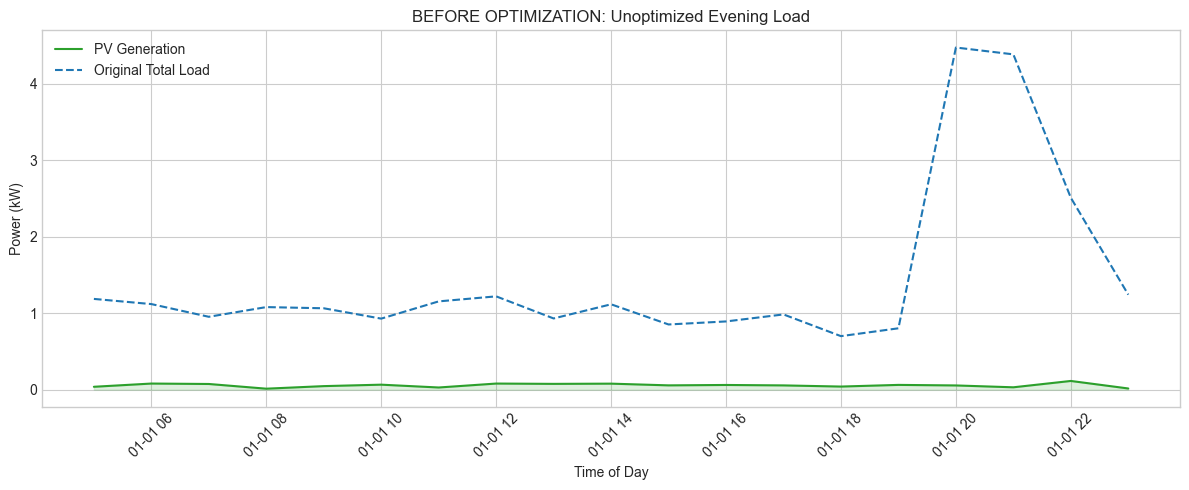

In [9]:
# Calculate safe baseline to prevent 'inf' crashes
safe_evening_idx = max(0, len(base_load) - 4) 
baseline_times = [safe_evening_idx] * len(appliances)
original_import = evaluate_schedule(baseline_times, appliances, pv_series, base_load)

original_total_load = np.copy(base_load)
for app in appliances:
    duration_slots = int(np.ceil(app.duration_h))
    if safe_evening_idx + duration_slots <= len(original_total_load):
        original_total_load[safe_evening_idx : safe_evening_idx + duration_slots] += app.power_kw

sc_original = self_consumption(pv_series, original_total_load)
ss_original = self_sufficiency(pv_series, original_total_load)

print("--- BASELINE METRICS (BEFORE) ---")
print(f"Grid Import:      {original_import:.2f} kWh")
print(f"Self-Consumption: {sc_original*100:.1f}%")
print(f"Self-Sufficiency: {ss_original*100:.1f}%\n")

plt.figure(figsize=(12, 5))
plt.plot(df.index, pv_series, label="PV Generation", color='#2ca02c')
plt.fill_between(df.index, 0, pv_series, color='#2ca02c', alpha=0.15)
plt.plot(df.index, original_total_load, label="Original Total Load", color='#1f77b4', linestyle='--')
plt.title("BEFORE OPTIMIZATION: Unoptimized Evening Load")
plt.xlabel("Time of Day")
plt.ylabel("Power (kW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Run Genetic Algorithm
scheduler = GAScheduler(appliances, pv_series, base_load, config.get("optimization"))
best_times, optimized_import = scheduler.run()

optimized_total_load = np.copy(base_load)
for i, app in enumerate(appliances):
    start = best_times[i]
    duration_slots = int(np.ceil(app.duration_h))
    if start + duration_slots <= len(optimized_total_load):
        optimized_total_load[start : start + duration_slots] += app.power_kw

sc_optimized = self_consumption(pv_series, optimized_total_load)
ss_optimized = self_sufficiency(pv_series, optimized_total_load)
energy_saved = max(0.0, original_import - optimized_import)

# Cost saved via the same cumulative-marginal Egyptian tariff used by the API.
# The OLD `energy_saved * flat_price` was a dead constant that ignored bracket
# structure -- a kWh saved at the 2.10 EGP tier is worth 3x a kWh at the 0.68 tier.
from app import calculate_egypt_daily_cost
cost_saved = max(0.0,
    calculate_egypt_daily_cost(original_import) - calculate_egypt_daily_cost(optimized_import)
)

print("="*60)
print(" THESIS OPTIMIZATION RESULTS ".center(60, "="))
print("="*60)
print(f"Original Grid Import:  {original_import:.2f} kWh")
print(f"Optimized Grid Import: {optimized_import:.2f} kWh")
print(f"Energy Saved:          {energy_saved:.2f} kWh")
print(f"Cost Saved (daily):    {cost_saved:.2f} EGP")
print(f"Self-Consumption:      {sc_original*100:.1f}% -> {sc_optimized*100:.1f}%")
print(f"Self-Sufficiency:      {ss_original*100:.1f}% -> {ss_optimized*100:.1f}%")
print("-" * 60)
print(f"{'Appliance':<20} | {'Start Time':<12} | {'Duration':<12} | {'Finish Time'}")
print("-" * 60)

for i, app in enumerate(appliances):
    start_h = best_times[i]
    duration_h = app.duration_h
    finish_h = start_h + duration_h
    
    start_str = f"{start_h:02d}:00"
    finish_str = f"{int(finish_h):02d}:{int((finish_h%1)*60):02d}"
    duration_str = f"{duration_h} hours"
    
    print(f"{app.name:<20} | {start_str:<12} | {duration_str:<12} | {finish_str}")
print("="*60)


In [11]:
print("--- OPTIMIZED LOAD PROFILE (AFTER OPTIMIZATION) ---")
# This uses your system's built-in plotting to overlay the red shifted line!
plot_schedule(df.index, pv_series, original_total_load, optimized_total_load, save_path=None)
plt.show()

--- OPTIMIZED LOAD PROFILE (AFTER OPTIMIZATION) ---
